In [61]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [77]:
# inline plotting in Jupyter
%matplotlib inline

file_path = "employee_performance_data_categorical.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Loaded dataset: {file_path}")
else:
    n = 200
    departments = ["HR", "Sales", "IT", "Finance", "Operations", "Support"]
    job_roles = ["Manager", "Analyst", "Developer", "Executive", "Consultant", "Technician"]
    salary_bands = ["Low", "Medium", "High"]
    performance_classes = ["Excellent", "Good", "Average", "Poor"]
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    df = pd.DataFrame({
        "employee_id": range(1001, 1001 + n),
        "department": np.random.choice(departments, n),
        "job_role": np.random.choice(job_roles, n),
        "years_at_company": np.random.randint(1, 15, n),
        "monthly_hours_worked": np.random.randint(120, 220, n),
        "attendance_rate": np.random.uniform(70, 100, n).round(2),
        "training_hours": np.random.randint(5, 50, n),
        "promotions_last_3years": np.random.randint(0, 3, n),
        "salary_band": np.random.choice(salary_bands, n, p=[0.4, 0.4, 0.2]),
        "performance_score": np.random.uniform(0, 30.89, n).round(2),
        "performance_class": np.random.choice(performance_classes, n, p=[0.2, 0.5, 0.25, 0.05]),
        "month": np.random.choice(months, n)
    })
    df.to_csv(file_path, index=False)
    print(f"Random dataset created and saved as {file_path}")

Loaded dataset: employee_performance_data_categorical.csv


In [78]:
df.head(24)

,employee_id,department,job_role,education_level,years_at_company,monthly_hours_worked,attendance_rate,training_hours,tasks_completed,peer_review_score,manager_rating,promotions_last_3years,salary_band,work_location,performance_score,performance_class,month
0,E1000,HR,Manager,PhD,7,154.5,97.6,5.9,4,9.55,6.03,1,Medium,Onsite,14.66,Low,2024-01
1,E1000,IT,Executive,PhD,6,174.6,100.0,0.1,3,8.41,4.05,2,Low,Hybrid,20.21,Low,2024-01
2,E1000,Marketing,Manager,PhD,9,161.2,92.4,3.8,4,8.92,8.65,0,Medium,Onsite,7.40,Low,2024-03
3,E1000,HR,Manager,Bachelors,6,163.2,88.0,0.6,12,5.93,5.31,0,Low,Hybrid,10.69,Low,2024-03
4,E1000,Marketing,Manager,PhD,9,153.2,98.1,NaN,3,8.90,7.66,0,Low,Hybrid,18.92,Low,2024-04
5,E1000,Marketing,Developer,Bachelors,7,148.9,89.0,6.6,9,9.53,7.17,0,Medium,Hybrid,12.73,Low,2024-05
6,E1000,Finance,Manager,Bachelors,4,157.8,96.8,8.0,3,6.72,8.83,1,High,Remote,15.25,Low,2024-06
7,E1000,Finance,Analyst,Bachelors,4,161.0,99.8,3.6,4,7.01,1.69,0,Low,Remote,14.38,Low,2024-07
8,E1000,HR,Manager,Masters,3,150.9,90.9,4.0,4,6.65,9.17,0,Low,Remote,17.84,Low,2024-08
9,E1000,Finance,Associate,Masters,8,161.0,92.8,3.7,6,7.51,9.29,0,Low,Hybrid,17.53,Low,2024-09


In [79]:
required_columns = [
    'employee_id', 'department', 'job_role', 'years_at_company',
    'monthly_hours_worked', 'attendance_rate', 'training_hours',
    'promotions_last_3years', 'salary_band', 'performance_score',
    'performance_class', 'month'
]

# Keep only required columns (ignore others)
df = df[required_columns].copy()
print("Filtered columns. Current columns:\n", df.columns.tolist())

Filtered columns. Current columns:
 ['employee_id', 'department', 'job_role', 'years_at_company', 'monthly_hours_worked', 'attendance_rate', 'training_hours', 'promotions_last_3years', 'salary_band', 'performance_score', 'performance_class', 'month']


In [80]:
# PREPROCESSING
print("\nMissing values before preprocessing:\n", df.isna().sum())


Missing values before preprocessing:
 employee_id                0
department                 0
job_role                   0
years_at_company           0
monthly_hours_worked       0
attendance_rate            0
training_hours            60
promotions_last_3years     0
salary_band                0
performance_score          0
performance_class          0
month                      0
dtype: int64


In [81]:
# Identify types
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Categorical columns: {cat_cols}")
print(f"Numeric columns: {num_cols}")

Categorical columns: ['employee_id', 'department', 'job_role', 'salary_band', 'performance_class', 'month']
Numeric columns: ['years_at_company', 'monthly_hours_worked', 'attendance_rate', 'training_hours', 'promotions_last_3years', 'performance_score']


In [82]:
# Missing Values
df['training_hours'] = df['training_hours'].fillna(df['training_hours'].median())
print("Missing values handled successfully.")

Missing values handled successfully.


In [83]:
# Categorical Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"Categorical columns encoded. Final encoded shape: {df_encoded.shape}")

Categorical columns encoded. Final encoded shape: (1200, 124)


In [84]:
# Stats
total_employees = df['employee_id'].nunique()
avg_years = df["years_at_company"].mean().round(1)
avg_monthly_hours = df["monthly_hours_worked"].mean().round(1)
avg_performance = df["performance_score"].mean().round(2)

In [85]:
# Month Handling for Time Trend
df = df.sort_values(["employee_id", "month"]).reset_index(drop=True)
df["month_num"] = df.groupby("employee_id").cumcount() + 1

In [86]:
df.head(24)

,employee_id,department,job_role,years_at_company,monthly_hours_worked,attendance_rate,training_hours,promotions_last_3years,salary_band,performance_score,performance_class,month,month_num
0,E1000,HR,Manager,7,154.5,97.6,5.9,1,Medium,14.66,Low,2024-01,1
1,E1000,IT,Executive,6,174.6,100.0,0.1,2,Low,20.21,Low,2024-01,2
2,E1000,Marketing,Manager,9,161.2,92.4,3.8,0,Medium,7.40,Low,2024-03,3
3,E1000,HR,Manager,6,163.2,88.0,0.6,0,Low,10.69,Low,2024-03,4
4,E1000,Marketing,Manager,9,153.2,98.1,5.0,0,Low,18.92,Low,2024-04,5
5,E1000,Marketing,Developer,7,148.9,89.0,6.6,0,Medium,12.73,Low,2024-05,6
6,E1000,Finance,Manager,4,157.8,96.8,8.0,1,High,15.25,Low,2024-06,7
7,E1000,Finance,Analyst,4,161.0,99.8,3.6,0,Low,14.38,Low,2024-07,8
8,E1000,HR,Manager,3,150.9,90.9,4.0,0,Low,17.84,Low,2024-08,9
9,E1000,Finance,Associate,8,161.0,92.8,3.7,0,Low,17.53,Low,2024-09,10


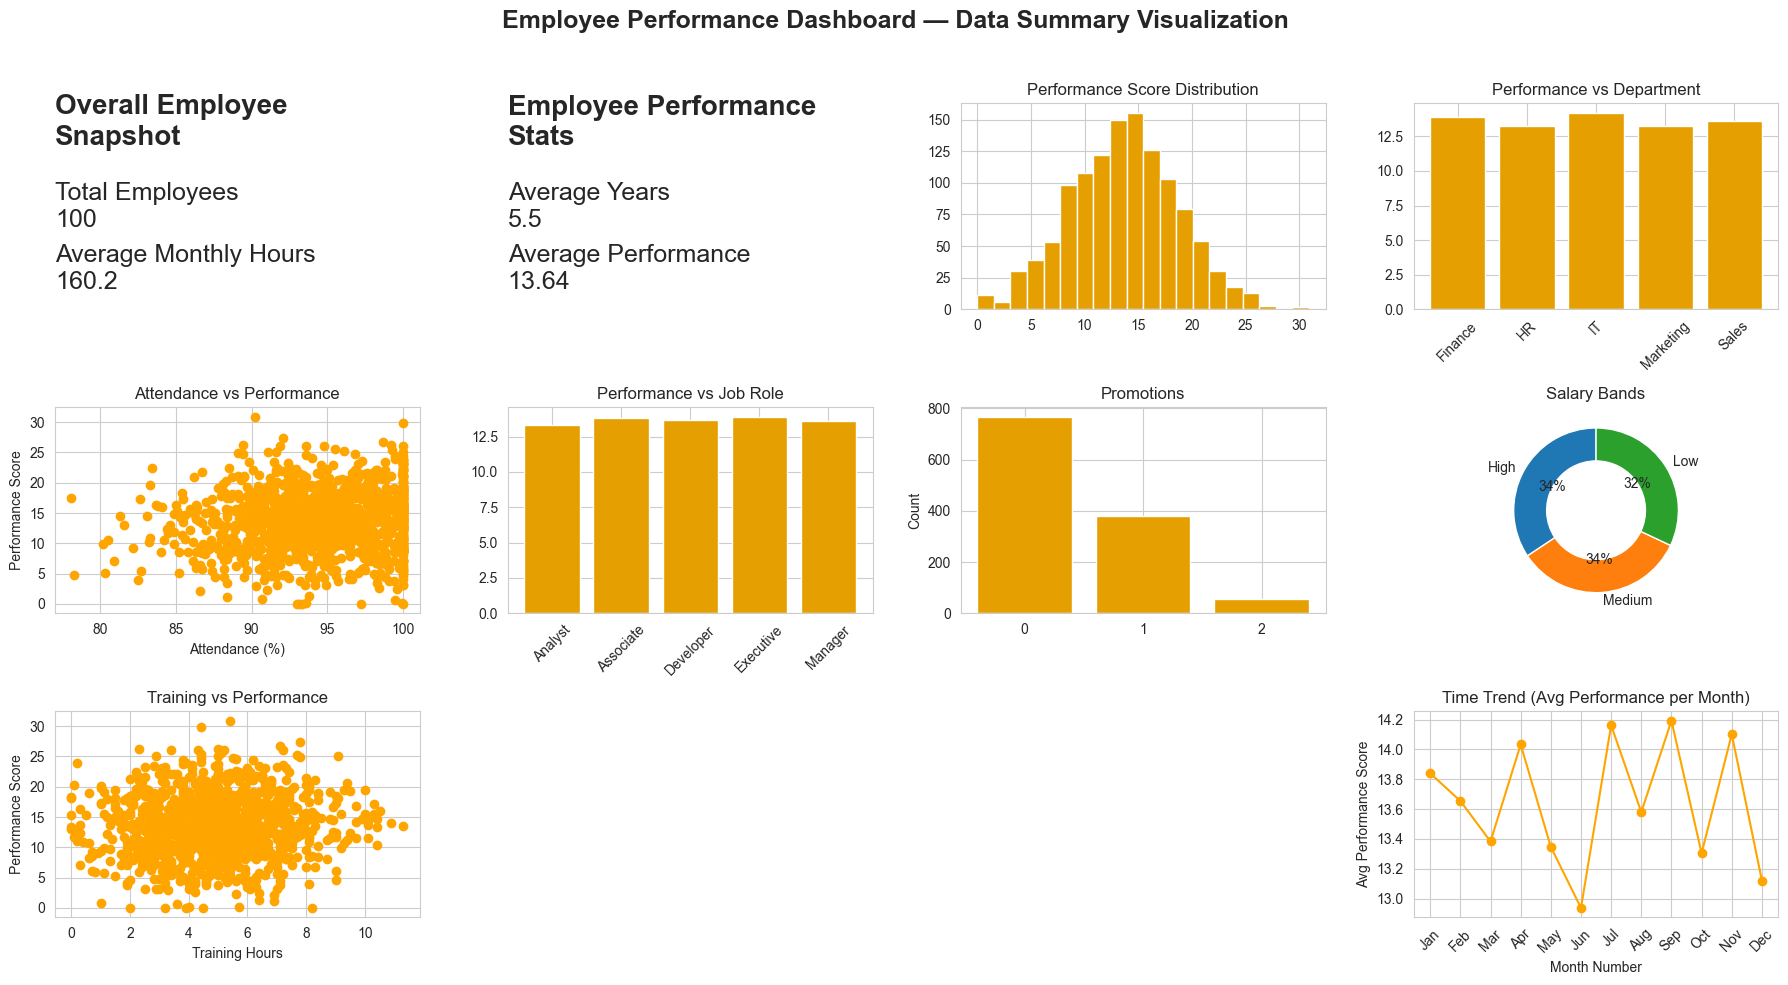

Dashboard generated and saved successfully.


In [91]:
# Visualization
fig, axs = plt.subplots(3, 4, figsize=(18, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.6)
fig.suptitle("Employee Performance Dashboard — Data Summary Visualization", fontsize=18, fontweight='bold')

# Overall Snapshot
axs[0, 0].axis("off")
axs[0, 0].text(0, 0.8, "Overall Employee\nSnapshot", fontsize=20, fontweight="bold")
axs[0, 0].text(0, 0.4, f"Total Employees\n{total_employees}", fontsize=18)
axs[0, 0].text(0, 0.1, f"\n\nAverage Monthly Hours\n{avg_monthly_hours}", fontsize=18)

# Performance Stats
axs[0, 1].axis("off")
axs[0, 1].text(0, 0.8, "Employee Performance\nStats", fontsize=20, fontweight="bold")
axs[0, 1].text(0, 0.4, f"Average Years\n{avg_years}", fontsize=18)
axs[0, 1].text(0, 0.1, f"Average Performance\n{avg_performance}", fontsize=18)

# Performance Distribution
axs[0, 2].hist(df["performance_score"], bins=20, color="#E69F00")
axs[0, 2].set_title("Performance Score Distribution")

# Department vs Performance
dept_perf = df.groupby("department")["performance_score"].mean()
axs[0, 3].bar(dept_perf.index, dept_perf.values, color="#E69F00")
axs[0, 3].set_title("Performance vs Department")
axs[0, 3].tick_params(axis="x", rotation=45)

# Attendance vs Performance
axs[1, 0].scatter(df["attendance_rate"], df["performance_score"], color="orange")
axs[1, 0].set_xlabel("Attendance (%)")
axs[1, 0].set_ylabel("Performance Score")
axs[1, 0].set_title("Attendance vs Performance")

# Job Role vs Performance
job_perf = df.groupby("job_role")["performance_score"].mean()
axs[1, 1].bar(job_perf.index, job_perf.values, color="#E69F00")
axs[1, 1].set_title("Performance vs Job Role")
axs[1, 1].tick_params(axis="x", rotation=45)

# Promotions
promo_counts = df["promotions_last_3years"].value_counts().sort_index()
axs[1, 2].bar(promo_counts.index.astype(str), promo_counts.values, color="#E69F00")
axs[1, 2].set_title("Promotions")
axs[1, 2].set_ylabel("Count")

# Salary Bands
salary_counts = df["salary_band"].value_counts()
axs[1, 3].pie(salary_counts, labels=salary_counts.index, autopct="%.0f%%", startangle=90, wedgeprops=dict(width=0.4))
axs[1, 3].set_title("Salary Bands")

# Training vs Performance
axs[2, 0].scatter(df["training_hours"], df["performance_score"], color="orange")
axs[2, 0].set_xlabel("Training Hours")
axs[2, 0].set_ylabel("Performance Score")
axs[2, 0].set_title("Training vs Performance")

# Time Trend
time_perf = df.groupby("month_num")["performance_score"].mean()
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axs[2, 3].plot(time_perf.index, time_perf.values, marker="o", color="orange")
axs[2, 3].set_xticks(time_perf.index)
axs[2, 3].set_xticklabels(month_labels[:len(time_perf.index)],rotation=45)
axs[2, 3].set_title("Time Trend (Avg Performance per Month)")
axs[2, 3].set_xlabel("Month Number")
axs[2, 3].set_ylabel("Avg Performance Score")

# Fill unused spaces
axs[2, 1].axis("off")
axs[2, 2].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("dashboard.png", dpi=300)
plt.show()

print("Dashboard generated and saved successfully.")